# Week 7: Decision Trees & Evaluation Metrics

## Building a Complete Classification Model with All 9 Metrics

In this notebook, we'll implement a complete Decision Tree classifier for credit default prediction. We'll cover:

1. **Import Libraries** - All necessary tools for ML and evaluation
2. **Load & Explore Data** - Understanding the dataset and class imbalance
3. **Data Preprocessing** - Cleaning, scaling, and splitting
4. **Build Decision Tree** - Training our baseline model
5. **Calculate 9 Metrics** - All evaluation metrics from Week 7 slides
6. **Analyze Imbalanced Data** - Why accuracy fails, what works
7. **Prune the Tree** - Preventing overfitting
8. **Cross-Validation** - Reliable model evaluation
9. **Hyperparameter Tuning** - Finding optimal parameters
10. **Final Evaluation** - Complete model assessment

**Dataset**: Credit Default (Imbalanced: 94% non-default, 6% default)

---
## Step 1: Import Libraries

We need libraries for:
- **Data handling**: pandas, numpy
- **Machine learning**: sklearn models and tools
- **Evaluation**: All 9 metrics from Week 7
- **Visualization**: matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## Step 2: Load & Explore Data

In [2]:
data = pd.read_csv('datasets/credits/credit.csv')

print(f"Dataset Shape: {data.shape}")
print(f"\nRows: {data.shape[0]}, Columns: {data.shape[1]}")
print(data.head())

Dataset Shape: (8026, 11)

Rows: 8026, Columns: 11
   Credit  RevolvingUtiOfUnsecuredLines  age  DebtRatio  MonthlyIncome  \
0       1                      0.766127   45   0.802982           9120   
1       0                      0.957151   40   0.121876           2600   
2       0                      0.658180   38   0.085113           3042   
3       0                      0.233810   30   0.036050           3300   
4       0                      0.907239   49   0.024926          63588   

   NoOfDependents  NoRealEstateLoansOrLines  NoOfOpenCreditLinesAndLoans  \
0               2                         6                           13   
1               1                         0                            4   
2               0                         0                            2   
3               0                         0                            5   
4               0                         1                            7   

   NoofTime30_59DaysPastDue  NoOfTime60_89DaysP

---
## Step 3: Analyze Class Distribution

### ⚠️ CRITICAL INSIGHT: Imbalanced Data

This dataset is **heavily imbalanced**: 94% non-defaults, 6% defaults.

**Why this matters:**
- A naive model predicting "No Default" for everyone gets **94% accuracy**
- But it catches **0% of actual defaults** → USELESS!
- **Accuracy ALONE is MISLEADING for imbalanced data**

**Solutions:**
1. Use **Recall**: What % of actual defaults do we catch?
2. Use **F1-Score**: Balance between precision and recall
3. Use **ROC-AUC**: Evaluate at ALL thresholds (BEST!)


Class Distribution:
No Default (0):   7509 (93.56%)
Default (1):       517 ( 6.44%)

Imbalance Ratio: 14.5:1


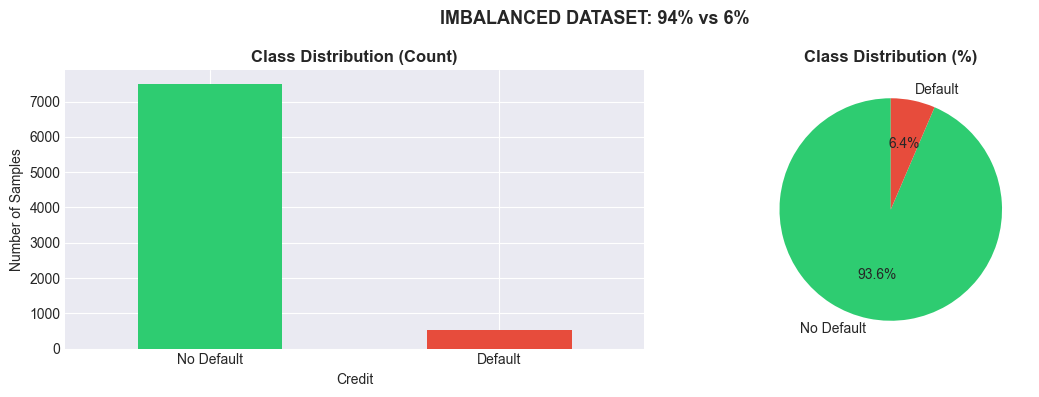

In [3]:
class_counts = data['Credit'].value_counts()
class_pct = data['Credit'].value_counts(normalize=True) * 100

print("\nClass Distribution:")
print(f"No Default (0): {class_counts[0]:>6} ({class_pct[0]:>5.2f}%)")
print(f"Default (1):    {class_counts[1]:>6} ({class_pct[1]:>5.2f}%)")
print(f"\nImbalance Ratio: {class_pct[0]/class_pct[1]:.1f}:1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)

axes[1].pie(class_counts, labels=['No Default', 'Default'], autopct='%1.1f%%',
           colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')
plt.suptitle('IMBALANCED DATASET: 94% vs 6%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Data Preprocessing

1. Separate features (X) from target (y)
2. Split into training and testing sets (**with stratification** for imbalanced data)
3. Scale features to same range

In [4]:
X = data.drop('Credit', axis=1)
y = data['Credit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\n✓ Features scaled (mean≈0, std≈1)")

Training set: 5618 samples
Testing set:  2408 samples

✓ Features scaled (mean≈0, std≈1)


---
## Step 5: Build Decision Tree (Baseline)

Train a decision tree with default parameters. This will likely **overfit** - we'll fix that later.

In [5]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)

y_train_pred = dt.predict(X_train_scaled)
y_train_proba = dt.predict_proba(X_train_scaled)[:, 1]

y_test_pred = dt.predict(X_test_scaled)
y_test_proba = dt.predict_proba(X_test_scaled)[:, 1]

print(f"Tree Depth: {dt.get_depth()}")
print(f"Tree Leaves: {dt.get_n_leaves()}")
print(f"\n⚠️  Very deep tree → Likely overfits")

Tree Depth: 22
Tree Leaves: 443

⚠️  Very deep tree → Likely overfits


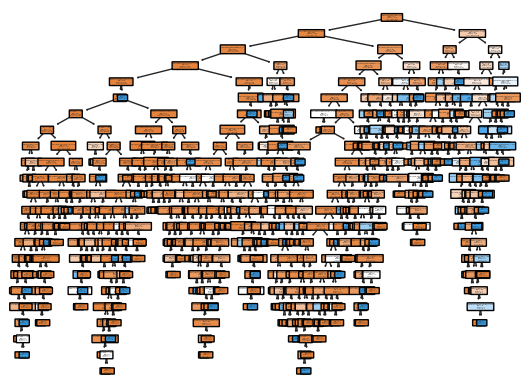

In [6]:
from sklearn.tree import plot_tree
plot_tree(dt, feature_names = X.columns, class_names = ['Non Default', 'Default'], filled=True, rounded=True)
plt.show()

---
## Step 6: Calculate All 9 Evaluation Metrics

### The 9 Metrics from Week 7:

| # | Metric | What It Measures | For Imbalanced? |
|---|--------|-----------------|----------------|
| 1 | Accuracy | Overall correctness | ❌ No |
| 2 | Precision | Of predicted defaults, % correct | ⚠️ Maybe |
| 3 | Recall | Of actual defaults, % caught | ✅ Yes |
| 4 | F1-Score | Harmonic mean of P & R | ✅ Yes |
| 5 | Specificity | True Negative Rate | ✅ Yes |
| 6 | FPR | False Positive Rate | ✅ Yes |
| 7 | Confusion Matrix | Error breakdown | ✅ Yes |
| 8 | ROC Curve | Threshold analysis plot | ✅ Yes |
| 9 | ROC-AUC | Area under curve | ✅✅✅ BEST |

**Key Insight**: For imbalanced data, **ROC-AUC > Accuracy**!

In [ ]:
def get_metrics(y_true, y_pred, y_proba):
    """Calculate all 9 metrics."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Specificity': tn / (tn + fp),
        'FPR': fp / (fp + tn),
        'CM': confusion_matrix(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_proba),
    }

train_m = get_metrics(y_train, y_train_pred, y_train_proba)
test_m = get_metrics(y_test, y_test_pred, y_test_proba)

---
## Step 7: Display & Analyze Metrics

### All 9 Metrics - Testing Set:

In [ ]:
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'FPR', 'TP', 'TN', 'FP', 'FN', 'ROC-AUC'],
    'Value': [
        f"{test_m['Accuracy']:.4f}",
        f"{test_m['Precision']:.4f}",
        f"{test_m['Recall']:.4f}",
        f"{test_m['F1']:.4f}",
        f"{test_m['Specificity']:.4f}",
        f"{test_m['FPR']:.4f}",
        f"{test_m['TP']}",
        f"{test_m['TN']}",
        f"{test_m['FP']}",
        f"{test_m['FN']}",
        f"{test_m['ROC_AUC']:.4f}",
    ]
})

print(metrics_summary.to_string(index=False))

---
## Step 8: Key Insights

### Why Each Metric Matters for Imbalanced Data:

#### ❌ ACCURACY - MISLEADING!
- Naive model always predicting "No Default" gets ~94% accuracy
- But catches 0% of actual defaults
- **Don't rely on accuracy alone!**

#### ✅ RECALL - CRITICAL!
- Shows % of actual defaults we catch
- Direct measure of minority class performance
- **This is what business cares about!**

#### ✅ F1-SCORE - GOOD BALANCE
- Much better than accuracy for imbalanced data
- Balances precision and recall
- Single metric for overall quality

#### ⭐⭐⭐ ROC-AUC - USE THIS!
- Best metric for imbalanced classification
- Threshold-independent (evaluates at ALL thresholds)
- Perfect for optimization in GridSearchCV
- Range: 0.5 (random) → 1.0 (perfect)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(train_m['CM'], annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Training Confusion Matrix', fontweight='bold')

sns.heatmap(test_m['CM'], annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Testing Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))

---
## Step 9: ROC Curve Visualization

The ROC curve plots True Positive Rate (Recall) vs False Positive Rate at all classification thresholds. It's the best visual for imbalanced classifiers.

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Testing Set', fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 10: Prune the Tree

The unpruned tree is too deep and **overfits**. Adding constraints improves generalization.

In [ ]:
dt_pruned = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=12,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

dt_pruned.fit(X_train_scaled, y_train)

y_test_pred_p = dt_pruned.predict(X_test_scaled)
y_test_proba_p = dt_pruned.predict_proba(X_test_scaled)[:, 1]
test_m_p = get_metrics(y_test, y_test_pred_p, y_test_proba_p)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Unpruned': [f"{test_m['Accuracy']:.4f}", f"{test_m['Recall']:.4f}", 
                 f"{test_m['F1']:.4f}", f"{test_m['ROC_AUC']:.4f}"],
    'Pruned': [f"{test_m_p['Accuracy']:.4f}", f"{test_m_p['Recall']:.4f}", 
               f"{test_m_p['F1']:.4f}", f"{test_m_p['ROC_AUC']:.4f}"]
})

print("\nComparison: Unpruned vs Pruned")
print(comparison.to_string(index=False))

---
## Step 11: Cross-Validation

5-fold **stratified** cross-validation for robust performance estimates (not dependent on single train-test split).

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for metric_name, scoring in [('Accuracy', 'accuracy'), ('Recall', 'recall'), ('ROC-AUC', 'roc_auc')]:
    scores = cross_val_score(dt_pruned, X_train_scaled, y_train, cv=skf, scoring=scoring)
    cv_results[metric_name] = scores

cv_df = pd.DataFrame(cv_results)
print("\n5-Fold Cross-Validation Results:")
print(cv_df.describe().round(4))

---
## Step 12: Hyperparameter Tuning

Find optimal parameters using **GridSearchCV**.

### 🎯 IMPORTANT: Optimize for ROC-AUC, NOT Accuracy!
For imbalanced data, ROC-AUC is the best optimization metric.

In [ ]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 8]
}

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)

gs.fit(X_train_scaled, y_train)

best_model = gs.best_estimator_
y_test_pred_best = best_model.predict(X_test_scaled)
y_test_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
test_m_best = get_metrics(y_test, y_test_pred_best, y_test_proba_best)

print(f"Best Parameters:")
for param, value in gs.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV Score (ROC-AUC): {gs.best_score_:.4f}")
print(f"\nFinal Test Performance:")
print(f"  Accuracy:  {test_m_best['Accuracy']:.4f}")
print(f"  Recall:    {test_m_best['Recall']:.4f}")
print(f"  ROC-AUC:   {test_m_best['ROC_AUC']:.4f}")

---
## Summary: Key Takeaways

### What We Learned:

#### 1. Class Imbalance Changes Everything
- Dataset: 94% non-default, 6% default
- Naive model gets 94% accuracy but catches 0% of defaults
- Accuracy alone is MISLEADING

#### 2. All 9 Metrics Serve Different Purposes
| Metric | Use Case | Imbalanced Data |
|--------|----------|----------------|
| Accuracy | Only for balanced data | ❌ No |
| Recall | Catches minority class | ✅ Yes |
| F1-Score | Good balance metric | ✅ Yes |
| ROC-AUC | All thresholds | ✅✅✅ BEST |

#### 3. Overfitting is Real
- Unpruned trees memorize training data
- Pruning improves generalization
- Cross-validation validates performance

#### 4. Optimization Matters
- GridSearchCV finds optimal hyperparameters
- **Use ROC-AUC as scoring metric for imbalanced data**
- Don't optimize for accuracy!

### Best Practices:
✓ Use **Stratified k-Fold** cross-validation  
✓ Optimize for **ROC-AUC**, not accuracy  
✓ Monitor **Recall** for business impact  
✓ Check **F1-Score** for overall quality  
✓ Use **class_weight='balanced'** in model

In [ ]:
print("\n" + "="*70)
print("🎓 WEEK 7: DECISION TREES & METRICS COMPLETE!")
print("="*70)

final_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [f"{test_m_best['Accuracy']:.4f}", f"{test_m_best['Precision']:.4f}",
              f"{test_m_best['Recall']:.4f}", f"{test_m_best['F1']:.4f}",
              f"{test_m_best['ROC_AUC']:.4f}"]
})

print("\nFinal Results:")
print(final_results.to_string(index=False))

print(f"\n✓ Best Parameters: {gs.best_params_}")
print(f"✓ Model ready for deployment")